In [58]:
# Importar librerías necesarias
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para visualización
plt.style.use('default')  # Reseteamos el estilo
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12


In [59]:
# Ruta al archivo de métricas
gpkg_path = r"C:\TRABAJO\06_proyectos\13_AF_uruguay2025\03_metricas\gpkg_grilla_metricas_combined_af.gpkg"

# Cargar datos
gdf = gpd.read_file(gpkg_path, engine='pyogrio')

# Calcular área en metros cuadrados
gdf['area_m2'] = gdf.geometry.area

# Filtrar por área >= 380 m²
gdf_filtered = gdf[gdf['area_m2'] >= 380]

# Información básica del dataset
print(f"Dimensiones del dataset original: {len(gdf)}")
print(f"Dimensiones después del filtro (área >= 380 m²): {len(gdf_filtered)}")
print(f"Grillas eliminadas por el filtro: {len(gdf) - len(gdf_filtered)}")

# Estadísticas del área antes y después del filtro
print("\nEstadísticas del área antes del filtro (m²):")
print(gdf['area_m2'].describe().round(2))
print("\nEstadísticas del área después del filtro (m²):")
print(gdf_filtered['area_m2'].describe().round(2))

print("\nColumnas disponibles:")
print(gdf_filtered.columns.tolist())
print("\nPrimeras filas:")
display(gdf_filtered.head())


c:\Users\HG-3027\.conda\envs\geomatico\lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read(


Dimensiones del dataset original: 163902
Dimensiones después del filtro (área >= 380 m²): 61177
Grillas eliminadas por el filtro: 102725

Estadísticas del área antes del filtro (m²):
count    163902.00
mean        251.75
std         149.42
min           0.00
25%         104.89
50%         298.34
75%         400.00
max         400.00
Name: area_m2, dtype: float64

Estadísticas del área después del filtro (m²):
count    61177.00
mean       398.57
std          3.95
min        380.01
25%        400.00
50%        400.00
75%        400.00
max        400.00
Name: area_m2, dtype: float64

Columnas disponibles:
['fid', 'OBJECTID', 'idpredio', 'idrodal', 'predio', 'tipouso', 'apl', 'supha', 'clave_roda', 'pointid', 'grid_code', 'COV', 'STD', 'AVG', 'DNS', 'MAX', 'MIN', 'P50', 'P75', 'P80', 'P90', 'P95', 'P99', 'VC2', 'VC1', 'VC0', 'HOM', 'B80', 'B30', 'BUFF_DIST', 'ORIG_FID', 'Shape_Length', 'Shape_Area', 'cat_cov', 'cat_p95', 'Entrega', 'layer', 'path', 'geometry', 'area_m2']

Primeras filas:


,fid,OBJECTID,idpredio,idrodal,predio,tipouso,apl,supha,clave_roda,pointid,...,ORIG_FID,Shape_Length,Shape_Area,cat_cov,cat_p95,Entrega,layer,path,geometry,area_m2
4,5,5,10001,1,Las Canias,EUGR,2007,62.583599,10001_0001,8469,...,8469,80.000000,400.000000,30,5,None,gpkg_grilla_metricas_b01_af — metricas_grilla_...,C:/TRABAJO/06_proyectos/13_AF_uruguay2025/03_m...,MULTIPOLYGON Z (((767820.000 6380380.000 0.000...,400.000000
8,9,9,10001,1,Las Canias,EUGR,2007,62.583599,10001_0001,8514,...,8514,77.849390,393.136333,30,5,None,gpkg_grilla_metricas_b01_af — metricas_grilla_...,C:/TRABAJO/06_proyectos/13_AF_uruguay2025/03_m...,MULTIPOLYGON Z (((767820.000 6380364.152 0.000...,393.136333
11,12,12,10001,1,Las Canias,EUGR,2007,62.583599,10001_0001,8559,...,8559,80.000000,400.000000,30,5,None,gpkg_grilla_metricas_b01_af — metricas_grilla_...,C:/TRABAJO/06_proyectos/13_AF_uruguay2025/03_m...,MULTIPOLYGON Z (((767800.000 6380340.000 0.000...,400.000000
12,13,13,10001,1,Las Canias,EUGR,2007,62.583599,10001_0001,8560,...,8560,80.203275,388.790041,30,5,None,gpkg_grilla_metricas_b01_af — metricas_grilla_...,C:/TRABAJO/06_proyectos/13_AF_uruguay2025/03_m...,MULTIPOLYGON Z (((767820.000 6380356.344 0.000...,388.790041
16,17,17,10001,1,Las Canias,EUGR,2007,62.583599,10001_0001,8607,...,8607,80.000000,400.000000,30,5,None,gpkg_grilla_metricas_b01_af — metricas_grilla_...,C:/TRABAJO/06_proyectos/13_AF_uruguay2025/03_m...,MULTIPOLYGON Z (((767800.000 6380320.000 0.000...,400.000000


Estadísticas descriptivas de p95 y cov:


,P95,COV
count,163902.000000,163902.000000
mean,40.200853,87.150097
std,6.497186,12.667029
min,0.065750,0.000000
25%,38.246750,84.900002
50%,41.670750,90.900002
75%,44.147937,94.400002
max,52.150749,99.099998


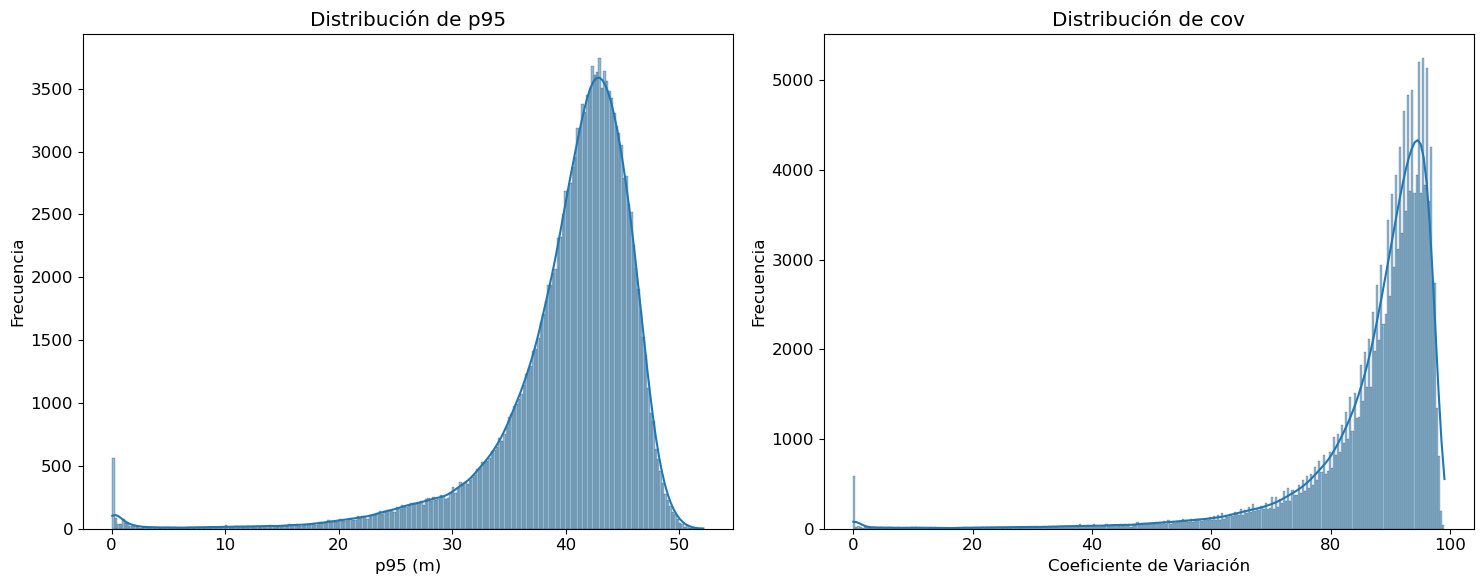

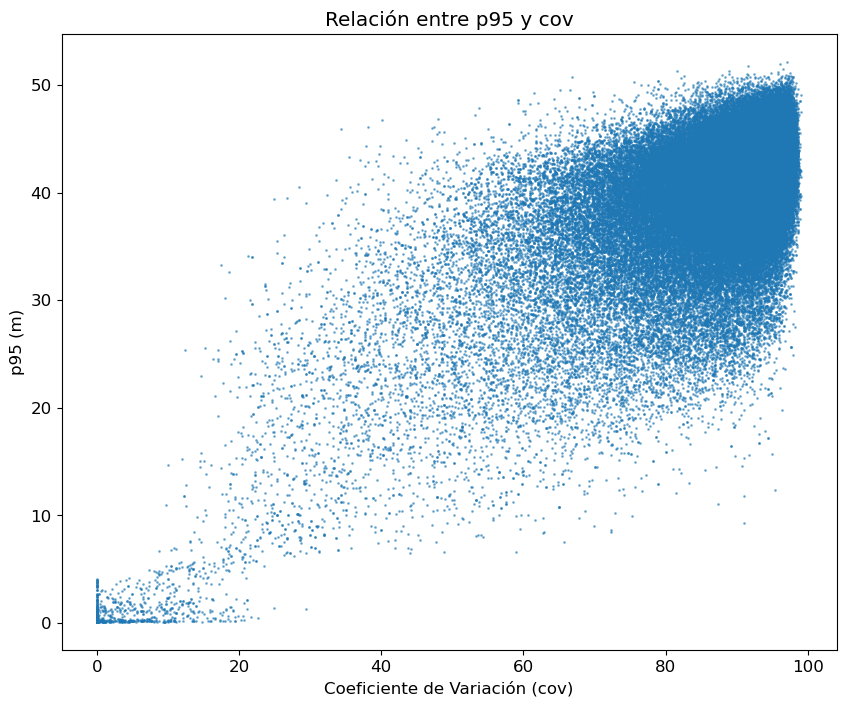

In [60]:
# Estadísticas descriptivas
print("Estadísticas descriptivas de p95 y cov:")
display(gdf[['P95', 'COV']].describe())

# Crear subplots para visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histograma para p95
sns.histplot(data=gdf, x='P95', kde=True, ax=ax1)
ax1.set_title('Distribución de p95')
ax1.set_xlabel('p95 (m)')
ax1.set_ylabel('Frecuencia')

# Histograma para cov
sns.histplot(data=gdf, x='COV', kde=True, ax=ax2)
ax2.set_title('Distribución de cov')
ax2.set_xlabel('Coeficiente de Variación')
ax2.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Gráfico de dispersión p95 vs cov
plt.figure(figsize=(10, 8))
plt.scatter(gdf['COV'], gdf['P95'], alpha=0.5, s=1)
plt.xlabel('Coeficiente de Variación (cov)')
plt.ylabel('p95 (m)')
plt.title('Relación entre p95 y cov')
plt.show()



ANÁLISIS PARA ESTRATIFICACIÓN

ANÁLISIS DE COV:
--------------------------------------------------

Estadísticas básicas:


count    61177.000000
mean        90.843153
std          7.590201
min          0.000000
25%         88.800003
50%         92.699997
75%         95.300003
max         99.099998
Name: COV, dtype: float64


Análisis de agrupamiento natural:
- Centroides de clusters: 33.5, 82.2, 93.6
- Picos de densidad: 4.5, 10.0, 13.4, 16.9, 22.9, 25.9, 28.9, 31.4, 35.4, 39.8, 43.3, 54.8, 95.6


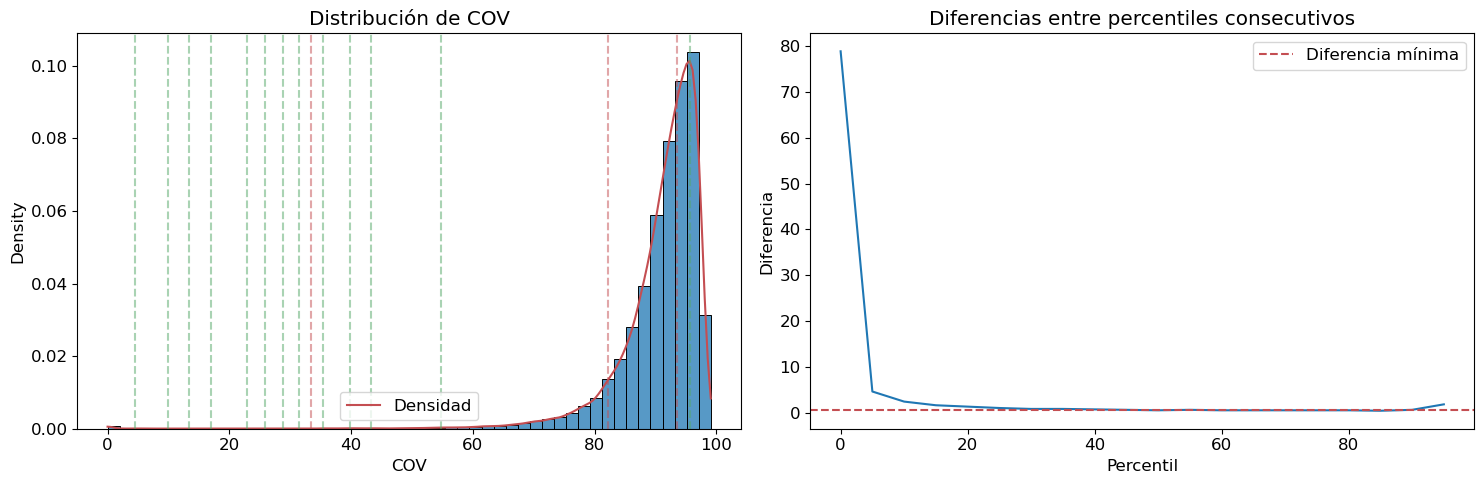


Propuesta de estratificación para COV:

Estratos sugeridos:
Estrato 1: 0-33
Estrato 2: 33-79
Estrato 3: 79-100

ANÁLISIS DE P95:
--------------------------------------------------

Estadísticas básicas:


count    61177.000000
mean        43.039167
std          3.774140
min          0.084750
25%         41.418499
50%         43.443001
75%         45.310501
max         51.483002
Name: P95, dtype: float64


Análisis de agrupamiento natural:
- Centroides de clusters: 7.3, 36.3, 40.9, 43.8, 46.6
- Picos de densidad: 3.7, 5.3, 8.9, 10.4, 12.5, 14.0, 18.2, 19.2, 20.7, 23.3, 25.4, 27.7, 43.7


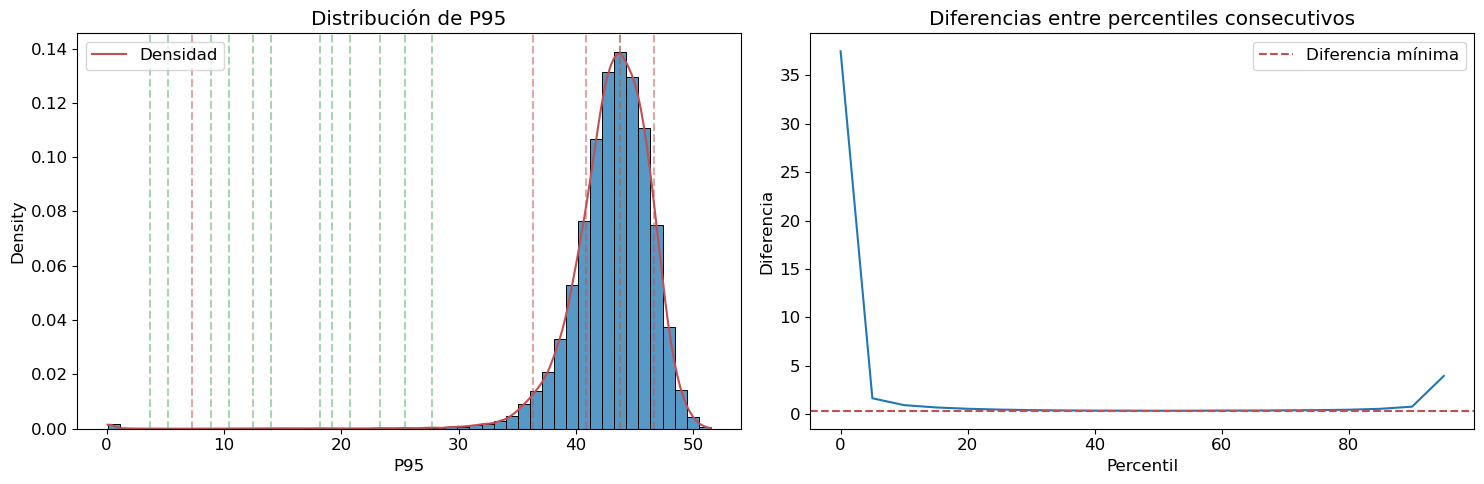


Propuesta de estratificación para P95:

Estratos sugeridos:
Estrato 1: 0-7
Estrato 2: 7-36
Estrato 3: 36-38
Estrato 4: 38-39
Estrato 5: 39-52

ANÁLISIS DE HOMOGENEIDAD ESPACIAL

Distribución final de GridCodes:


,GridCode,Cantidad,Porcentaje
0,11,120,0.20
1,12,28,0.05
2,13,1,0.00
3,15,1,0.00
4,22,364,0.59
5,23,153,0.25
6,24,320,0.52
7,25,2111,3.45
8,32,1304,2.13
9,33,1089,1.78



Distribución de GridCodes:


gridcode
11      120
12       28
13        1
15        1
22      364
23      153
24      320
25     2111
32     1304
33     1089
34     2739
35    52947
Name: count, dtype: int64

In [61]:
# Usar el GeoDataFrame filtrado
gdf = gdf_filtered

def analizar_variable(data, var_name, n_estratos, min_diff_percentile=5):
    """
    Analiza una variable para encontrar estratos óptimos considerando:
    1. Diferencias significativas entre estratos
    2. Distribución natural de los datos (clusters)
    3. Mínima diferencia requerida entre estratos
    """
    from sklearn.cluster import KMeans
    from scipy.stats import gaussian_kde
    
    print(f"\nANÁLISIS DE {var_name}:")
    print("-" * 50)
    
    # 1. Análisis básico
    stats = data.describe()
    print("\nEstadísticas básicas:")
    display(stats)
    
    # 2. Análisis de densidad para encontrar picos naturales
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    density = kde(x_range)
    peaks = []
    for i in range(1, len(density)-1):
        if density[i] > density[i-1] and density[i] > density[i+1]:
            peaks.append(x_range[i])
    
    # 3. Clustering para identificar grupos naturales
    kmeans = KMeans(n_clusters=n_estratos, random_state=42)
    kmeans.fit(data.values.reshape(-1, 1))
    centroids = sorted(kmeans.cluster_centers_.flatten())
    
    # 4. Análisis de diferencias entre percentiles
    percentiles = range(0, 101, 5)  # Cada 5%
    perc_values = np.percentile(data, percentiles)
    diffs = np.diff(perc_values)
    
    # Encontrar intervalos donde hay diferencias significativas
    min_diff = np.percentile(diffs, min_diff_percentile)
    significant_gaps = np.where(diffs > min_diff)[0]
    
    # 5. Propuesta de estratos combinando toda la información
    print(f"\nAnálisis de agrupamiento natural:")
    print(f"- Centroides de clusters: {', '.join([f'{x:.1f}' for x in centroids])}")
    print(f"- Picos de densidad: {', '.join([f'{x:.1f}' for x in peaks])}")
    
    # Visualización
    plt.figure(figsize=(15, 5))
    
    # Histograma y densidad
    plt.subplot(121)
    sns.histplot(data=data, bins=50, stat='density')
    plt.plot(x_range, density, 'r-', label='Densidad')
    for p in peaks:
        plt.axvline(p, color='g', linestyle='--', alpha=0.5)
    for c in centroids:
        plt.axvline(c, color='r', linestyle='--', alpha=0.5)
    plt.title(f'Distribución de {var_name}')
    plt.legend()
    
    # Gráfico de diferencias entre percentiles
    plt.subplot(122)
    plt.plot(percentiles[:-1], diffs)
    plt.axhline(min_diff, color='r', linestyle='--', label='Diferencia mínima')
    plt.title('Diferencias entre percentiles consecutivos')
    plt.xlabel('Percentil')
    plt.ylabel('Diferencia')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 6. Propuesta final de estratos
    print(f"\nPropuesta de estratificación para {var_name}:")
    
    # Usar una combinación de clusters y diferencias significativas
    breaks = []
    breaks.append(np.floor(data.min()))
    
    # Añadir puntos de corte basados en clusters y gaps significativos
    potential_breaks = set()
    potential_breaks.update(centroids)
    for idx in significant_gaps:
        potential_breaks.add(perc_values[idx])
    
    potential_breaks = sorted(list(potential_breaks))
    
    # Seleccionar los mejores n_estratos-1 puntos de corte
    selected_breaks = []
    for i in range(1, len(potential_breaks)):
        if potential_breaks[i] - potential_breaks[i-1] >= min_diff:
            selected_breaks.append(potential_breaks[i])
    
    selected_breaks = sorted(selected_breaks)
    if len(selected_breaks) > n_estratos-1:
        selected_breaks = selected_breaks[:n_estratos-1]
    
    breaks.extend(selected_breaks)
    breaks.append(np.ceil(data.max()))
    
    # Mostrar estratos propuestos
    print("\nEstratos sugeridos:")
    for i in range(len(breaks)-1):
        print(f"Estrato {i+1}: {breaks[i]:.0f}-{breaks[i+1]:.0f}")
        
    return breaks

# Análisis para COV (3 estratos)
print("\nANÁLISIS PARA ESTRATIFICACIÓN")
print("=" * 50)
cov_breaks = analizar_variable(gdf['COV'], 'COV', 3)

# Análisis para P95 (5 estratos)
p95_breaks = analizar_variable(gdf['P95'], 'P95', 5)

# Crear estratos usando los breaks sugeridos
gdf['cat_cov'] = pd.cut(gdf['COV'], bins=cov_breaks, labels=[str(i) for i in range(1, len(cov_breaks))], include_lowest=True)
gdf['cat_p95'] = pd.cut(gdf['P95'], bins=p95_breaks, labels=[str(i) for i in range(1, len(p95_breaks))], include_lowest=True)

# Análisis espacial de homogeneidad
print("\nANÁLISIS DE HOMOGENEIDAD ESPACIAL")
print("=" * 50)

# Crear gridcode
gdf['gridcode'] = gdf['cat_cov'].astype(str) + gdf['cat_p95'].astype(str)
gdf['gridcode'] = gdf['gridcode'].astype(int)

# Mostrar distribución final
print("\nDistribución final de GridCodes:")
gridcode_dist = gdf['gridcode'].value_counts().sort_index()
display(pd.DataFrame({
    'GridCode': gridcode_dist.index,
    'Cantidad': gridcode_dist.values,
    'Porcentaje': (gridcode_dist.values / len(gdf) * 100).round(2)
}))

# Crear gridcode
gdf['gridcode'] = gdf['cat_cov'].astype(str) + gdf['cat_p95'].astype(str)

# Convertir gridcode a número
gdf['gridcode'] = gdf['gridcode'].astype(int)

# Mostrar distribución de gridcode
print("\nDistribución de GridCodes:")
display(gdf['gridcode'].value_counts().sort_index())


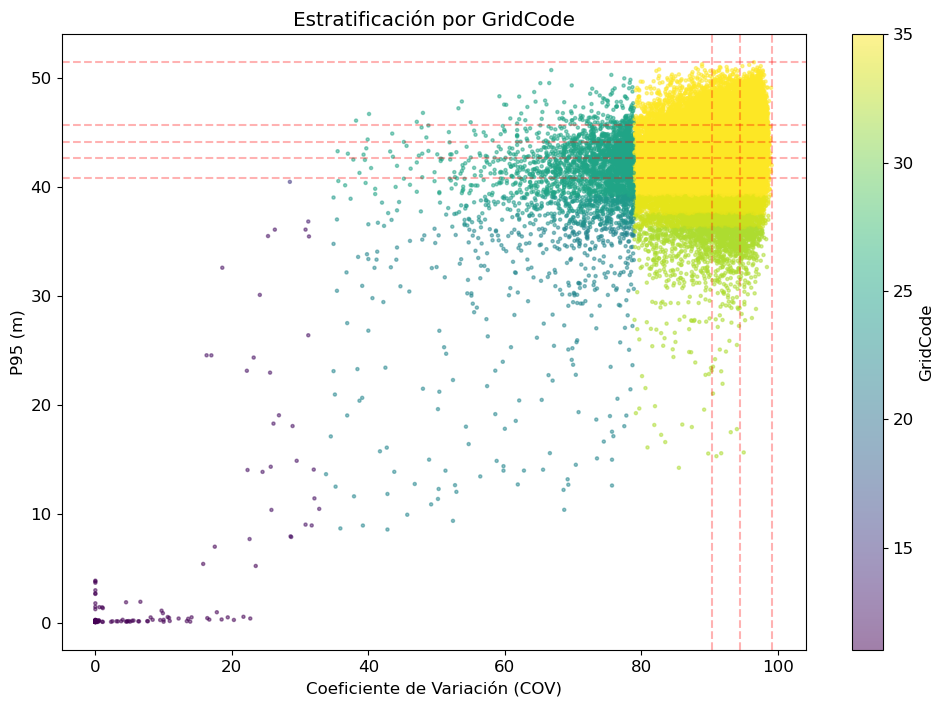

In [62]:
# Crear un gráfico de dispersión coloreado por gridcode
plt.figure(figsize=(12, 8))
scatter = plt.scatter(gdf['COV'], gdf['P95'], 
                     c=gdf['gridcode'], 
                     cmap='viridis',
                     alpha=0.5,
                     s=5)

plt.colorbar(scatter, label='GridCode')
plt.xlabel('Coeficiente de Variación (COV)')
plt.ylabel('P95 (m)')
plt.title('Estratificación por GridCode')

# Añadir líneas de división de los estratos
for q in pd.qcut(gdf['COV'], q=3).unique():
    plt.axvline(x=q.right, color='red', linestyle='--', alpha=0.3)
    
for q in pd.qcut(gdf['P95'], q=5).unique():
    plt.axhline(y=q.right, color='red', linestyle='--', alpha=0.3)

plt.show()


In [63]:
# Convertir columnas categóricas a string antes de guardar
gdf['cat_cov'] = gdf['cat_cov'].astype(str)
gdf['cat_p95'] = gdf['cat_p95'].astype(str)

# Eliminar la columna fid si existe y resetear el índice
if 'fid' in gdf.columns:
    gdf = gdf.drop('fid', axis=1)
gdf = gdf.reset_index(drop=True)

# Ruta para guardar resultados
output_path = r"C:\TRABAJO\06_proyectos\13_AF_uruguay2025\03_metricas\grilla_metricas_con_gridcode.gpkg"

# Guardar el GeoDataFrame con los nuevos campos
gdf.to_file(output_path, driver='GPKG', layer='metricas_estratificadas')
print(f"Resultados guardados en: {output_path}")
print(f"Capa: metricas_estratificadas")

# Generar resumen final
print("\nResumen de la estratificación:")
print(f"Total de polígonos: {len(gdf)}")
print(f"Número de estratos COV: {len(gdf['cat_cov'].unique())}")
print(f"Número de estratos P95: {len(gdf['cat_p95'].unique())}")
print(f"Número total de gridcodes: {len(gdf['gridcode'].unique())}")

# Mostrar tabla de distribución final
print("\nDistribución final de gridcodes:")
gridcode_dist = gdf['gridcode'].value_counts().sort_index()
df_resumen = pd.DataFrame({
    'GridCode': gridcode_dist.index,
    'Cantidad': gridcode_dist.values,
    'Porcentaje': (gridcode_dist.values / len(gdf) * 100).round(2)
})
display(df_resumen)

# Guardar también el resumen en formato Excel
resumen_path = output_path.replace('.gpkg', '_resumen.xlsx')
df_resumen.to_excel(resumen_path, index=False)
print(f"\nResumen guardado en Excel: {resumen_path}")


Resultados guardados en: C:\TRABAJO\06_proyectos\13_AF_uruguay2025\03_metricas\grilla_metricas_con_gridcode.gpkg
Capa: metricas_estratificadas

Resumen de la estratificación:
Total de polígonos: 61177
Número de estratos COV: 3
Número de estratos P95: 5
Número total de gridcodes: 12

Distribución final de gridcodes:


,GridCode,Cantidad,Porcentaje
0,11,120,0.20
1,12,28,0.05
2,13,1,0.00
3,15,1,0.00
4,22,364,0.59
5,23,153,0.25
6,24,320,0.52
7,25,2111,3.45
8,32,1304,2.13
9,33,1089,1.78



Resumen guardado en Excel: C:\TRABAJO\06_proyectos\13_AF_uruguay2025\03_metricas\grilla_metricas_con_gridcode_resumen.xlsx
